# Larger Transformer Study for Shallow Parsing (CoNLL-2000)

Goal: test whether larger transformer models produce meaningful gains over a lighter baseline for chunking.

This notebook runs a controlled comparison with:
- same dataset and label mapping
- same training/evaluation recipe
- model-size and runtime tracking

Then it summarizes whether extra compute is worth the gains.

In [1]:
import time
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset, DatasetDict
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

/home/sg/dev/nlp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Environment compatibility checks
import inspect
import accelerate

if "keep_torch_compile" not in inspect.signature(accelerate.Accelerator.unwrap_model).parameters:
    _orig_unwrap_model = accelerate.Accelerator.unwrap_model

    def _unwrap_model_compat(self, model, keep_torch_compile=None):
        return _orig_unwrap_model(self, model)

    accelerate.Accelerator.unwrap_model = _unwrap_model_compat
    print("Applied accelerate compatibility patch for unwrap_model().")
else:
    print("Accelerate API is compatible.")

Applied accelerate compatibility patch for unwrap_model().


In [3]:
# Load dataset
DATA_DIR = Path("../dataset")
TRAIN_PATH = DATA_DIR / "train.parquet"
TEST_PATH = DATA_DIR / "test.parquet"

CHUNK_LABELS = [
    "O", "B-ADJP", "I-ADJP", "B-ADVP", "I-ADVP", "B-CONJP", "I-CONJP", "B-INTJ", "I-INTJ", "B-LST",
    "I-LST", "B-NP", "I-NP", "B-PP", "I-PP", "B-PRT", "I-PRT", "B-SBAR", "I-SBAR", "B-UCP", "I-UCP",
    "B-VP", "I-VP"
]

def read_parquet_safe(path):
    for engine in ("fastparquet", "pyarrow"):
        try:
            return pd.read_parquet(path, engine=engine)
        except Exception:
            pass
    raise RuntimeError(f"Could not read {path}")

train_df = read_parquet_safe(TRAIN_PATH)
test_df = read_parquet_safe(TEST_PATH)

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)

train shape: (8937, 4)
test shape: (2013, 4)


In [4]:
# Prepare HF datasets
def to_hf_df(df):
    return pd.DataFrame({
        "id": df["id"].astype(str),
        "tokens": df["tokens"],
        "chunk_tags": df["chunk_tags"],
    })

hf_datasets = DatasetDict({
    "train": Dataset.from_pandas(to_hf_df(train_df), preserve_index=False),
    "test": Dataset.from_pandas(to_hf_df(test_df), preserve_index=False),
})

hf_datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'chunk_tags'],
        num_rows: 8937
    })
    test: Dataset({
        features: ['id', 'tokens', 'chunk_tags'],
        num_rows: 2013
    })
})

In [5]:
# Experiment configuration
MODEL_LIST = [
    # Existing comparison set
    "distilbert/distilbert-base-uncased",
    "bert-base-uncased",
    "roberta-base",

    # Added lightweight models (requested)
    # NanoBERT-like compact BERT (2-layer Google BERT variant)
    "google/bert_uncased_L-2_H-128_A-2",
    # BERT-Tiny
    "prajjwal1/bert-tiny",
    # TinyBERT
    "huawei-noah/TinyBERT_General_4L_312D",
]

MAX_TRAIN_SAMPLES = None   # e.g. 3000 for quick testing
MAX_TEST_SAMPLES = None    # e.g. 1000 for quick testing
NUM_EPOCHS = 2
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16
LEARNING_RATE = 2e-5

id2label = {i: v for i, v in enumerate(CHUNK_LABELS)}
label2id = {v: i for i, v in enumerate(CHUNK_LABELS)}

train_ds = hf_datasets["train"]
test_ds = hf_datasets["test"]
if MAX_TRAIN_SAMPLES is not None:
    train_ds = train_ds.select(range(min(MAX_TRAIN_SAMPLES, len(train_ds))))
if MAX_TEST_SAMPLES is not None:
    test_ds = test_ds.select(range(min(MAX_TEST_SAMPLES, len(test_ds))))

print("Train samples used:", len(train_ds))
print("Test samples used:", len(test_ds))

Train samples used: 8937
Test samples used: 2013


In [6]:
seqeval = evaluate.load("seqeval")

def get_tokenizer(model_name):
    # RoBERTa tokenizers work better with add_prefix_space for pre-tokenized input.
    if "roberta" in model_name:
        return AutoTokenizer.from_pretrained(model_name, add_prefix_space=True)
    return AutoTokenizer.from_pretrained(model_name)

def build_tokenized_dataset(tokenizer, train_dataset, test_dataset):
    def tokenize_and_align_labels(examples):
        tokenized = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)
        labels = []
        for i, label_seq in enumerate(examples["chunk_tags"]):
            word_ids = tokenized.word_ids(batch_index=i)
            prev = None
            aligned = []
            for word_idx in word_ids:
                if word_idx is None:
                    aligned.append(-100)
                elif word_idx != prev:
                    aligned.append(int(label_seq[word_idx]))
                else:
                    aligned.append(-100)
                prev = word_idx
            labels.append(aligned)
        tokenized["labels"] = labels
        return tokenized

    tokenized_train = train_dataset.map(tokenize_and_align_labels, batched=True)
    tokenized_test = test_dataset.map(tokenize_and_align_labels, batched=True)
    return tokenized_train, tokenized_test

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=2)

    true_preds, true_labels = [], []
    for pred_seq, label_seq in zip(preds, labels):
        p_seq, l_seq = [], []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                p_seq.append(CHUNK_LABELS[int(p)])
                l_seq.append(CHUNK_LABELS[int(l)])
        true_preds.append(p_seq)
        true_labels.append(l_seq)

    out = seqeval.compute(predictions=true_preds, references=true_labels)
    return {
        "precision": out["overall_precision"],
        "recall": out["overall_recall"],
        "f1": out["overall_f1"],
        "accuracy": out["overall_accuracy"],
    }

In [7]:
# Train and evaluate one model
from transformers.utils.notebook import NotebookProgressCallback

def count_parameters(model):
    return int(sum(p.numel() for p in model.parameters()))

def run_experiment(model_name):
    print(f"\n===== Running: {model_name} =====")

    tokenizer = get_tokenizer(model_name)
    tokenized_train, tokenized_test = build_tokenized_dataset(tokenizer, train_ds, test_ds)

    model = AutoModelForTokenClassification.from_pretrained(
        model_name,
        num_labels=len(CHUNK_LABELS),
        id2label=id2label,
        label2id=label2id,
    )

    data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

    safe_name = model_name.split("/")[-1].replace(".", "_")
    out_dir = f"outputs/scale-study-{safe_name}"

    args = TrainingArguments(
        output_dir=out_dir,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=100,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to="none",
        disable_tqdm=True,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    try:
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass

    t0 = time.time()
    trainer.train()
    train_seconds = time.time() - t0

    eval_metrics = trainer.evaluate()

    result = {
        "model": model_name,
        "params_millions": count_parameters(model) / 1e6,
        "train_seconds": train_seconds,
        "eval_loss": float(eval_metrics.get("eval_loss", np.nan)),
        "precision": float(eval_metrics.get("eval_precision", np.nan)),
        "recall": float(eval_metrics.get("eval_recall", np.nan)),
        "f1": float(eval_metrics.get("eval_f1", np.nan)),
        "accuracy": float(eval_metrics.get("eval_accuracy", np.nan)),
    }
    return result

In [8]:
# Run full model scaling study
results = []
for model_name in MODEL_LIST:
    try:
        res = run_experiment(model_name)
        results.append(res)
    except Exception as e:
        print(f"Failed on {model_name}: {e}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)
display(results_df.round(4))


===== Running: distilbert/distilbert-base-uncased =====


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7063.97it/s]
DistilBertForTokenClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '1.077', 'grad_norm': '2.033', 'learning_rate': '1.823e-05', 'epoch': '0.1789'}
{'loss': '0.2424', 'grad_norm': '1.628', 'learning_rate': '1.644e-05', 'epoch': '0.3578'}
{'loss': '0.1841', 'grad_norm': '1.941', 'learning_rate': '1.465e-05', 'epoch': '0.5367'}
{'loss': '0.1502', 'grad_norm': '1.343', 'learning_rate': '1.286e-05', 'epoch': '0.7156'}
{'loss': '0.1243', 'grad_norm': '1.187', 'learning_rate': '1.107e-05', 'epoch': '0.8945'}


/home/sg/dev/nlp/.venv/lib/python3.12/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'eval_loss': '0.119', 'eval_precision': '0.9449', 'eval_recall': '0.9539', 'eval_f1': '0.9494', 'eval_accuracy': '0.9692', 'eval_runtime': '3.837', 'eval_samples_per_second': '524.6', 'eval_steps_per_second': '32.84', 'epoch': '1'}


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  8.05it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

{'train_runtime': '32.49', 'train_samples_per_second': '550.2', 'train_steps_per_second': '34.41', 'train_loss': '0.738', 'epoch': '2'}


/home/sg/dev/nlp/.venv/lib/python3.12/site-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


{'eval_loss': '0.3825', 'eval_precision': '0.875', 'eval_recall': '0.8863', 'eval_f1': '0.8806', 'eval_accuracy': '0.9339', 'eval_runtime': '1.895', 'eval_samples_per_second': '1062', 'eval_steps_per_second': '66.49', 'epoch': '2'}


,model,params_millions,train_seconds,eval_loss,precision,recall,f1,accuracy
0,bert-base-uncased,108.9093,223.8648,0.1039,0.9582,0.9622,0.9602,0.9751
1,distilbert/distilbert-base-uncased,66.3806,120.0361,0.1100,0.9531,0.9596,0.9563,0.9727
2,huawei-noah/TinyBERT_General_4L_312D,14.2598,32.7503,0.3825,0.8750,0.8863,0.8806,0.9339
3,google/bert_uncased_L-2_H-128_A-2,4.3724,17.1686,0.8747,0.7213,0.7608,0.7405,0.8465


,model,params_millions,train_seconds,eval_loss,precision,recall,f1,accuracy,f1_gain_vs_base,train_time_ratio_vs_base,params_ratio_vs_base,gain_per_extra_hour
0,bert-base-uncased,108.9093,223.8648,0.1039,0.9582,0.9622,0.9602,0.9751,0.0039,1.8650,1.6407,0.1344
1,distilbert/distilbert-base-uncased,66.3806,120.0361,0.1100,0.9531,0.9596,0.9563,0.9727,0.0000,1.0000,1.0000,NaN
2,huawei-noah/TinyBERT_General_4L_312D,14.2598,32.7503,0.3825,0.8750,0.8863,0.8806,0.9339,-0.0757,0.2728,0.2148,NaN
3,google/bert_uncased_L-2_H-128_A-2,4.3724,17.1686,0.8747,0.7213,0.7608,0.7405,0.8465,-0.2158,0.1430,0.0659,NaN


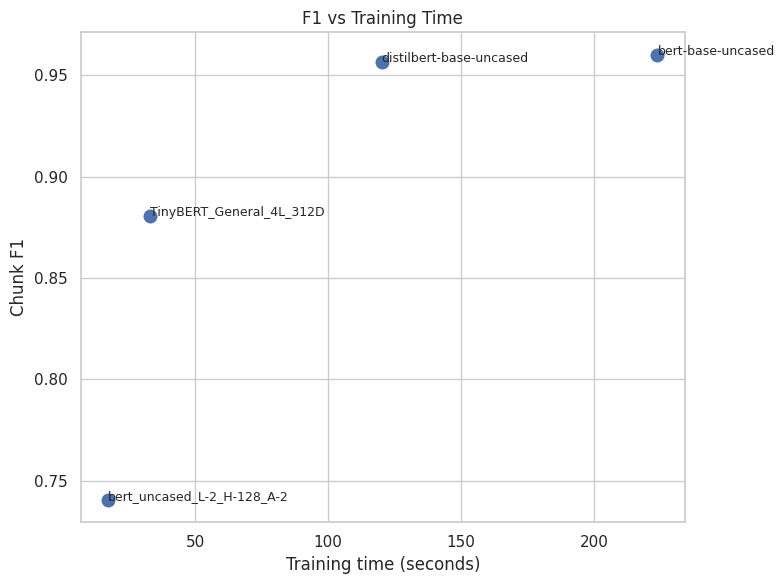

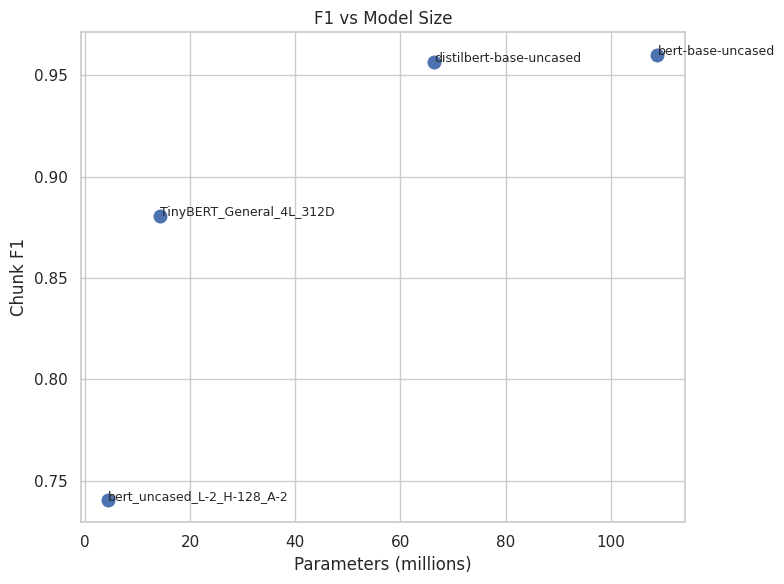

In [9]:
# Gain vs compute analysis
if len(results_df) == 0:
    raise RuntimeError("No successful runs.")

# Use DistilBERT as cost-efficient baseline when available.
baseline_mask = results_df["model"].str.contains("distilbert", case=False, regex=False)
if baseline_mask.any():
    base_row = results_df[baseline_mask].iloc[0]
else:
    base_row = results_df.iloc[-1]

analysis_df = results_df.copy()
analysis_df["f1_gain_vs_base"] = analysis_df["f1"] - float(base_row["f1"])
analysis_df["train_time_ratio_vs_base"] = analysis_df["train_seconds"] / float(base_row["train_seconds"])
analysis_df["params_ratio_vs_base"] = analysis_df["params_millions"] / float(base_row["params_millions"])
analysis_df["gain_per_extra_hour"] = np.where(
    analysis_df["train_seconds"] > float(base_row["train_seconds"]),
    analysis_df["f1_gain_vs_base"] / ((analysis_df["train_seconds"] - float(base_row["train_seconds"])) / 3600.0),
    np.nan,
)

display(analysis_df.round(4))

plt.figure(figsize=(8, 6))
sns.scatterplot(data=analysis_df, x="train_seconds", y="f1", s=120)
for _, r in analysis_df.iterrows():
    plt.text(r["train_seconds"], r["f1"], r["model"].split("/")[-1], fontsize=9)
plt.title("F1 vs Training Time")
plt.xlabel("Training time (seconds)")
plt.ylabel("Chunk F1")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=analysis_df, x="params_millions", y="f1", s=120)
for _, r in analysis_df.iterrows():
    plt.text(r["params_millions"], r["f1"], r["model"].split("/")[-1], fontsize=9)
plt.title("F1 vs Model Size")
plt.xlabel("Parameters (millions)")
plt.ylabel("Chunk F1")
plt.tight_layout()
plt.show()

In [10]:
# Simple recommendation rule
# You can adjust this threshold based on your team constraints.
MIN_MEANINGFUL_F1_GAIN = 0.005  # 0.5 F1 points
MAX_TIME_MULTIPLIER = 2.0

base_name = base_row["model"]
base_f1 = float(base_row["f1"])
base_time = float(base_row["train_seconds"])

candidates = analysis_df[analysis_df["model"] != base_name].copy()
worth_it = candidates[
    (candidates["f1_gain_vs_base"] >= MIN_MEANINGFUL_F1_GAIN) &
    (candidates["train_time_ratio_vs_base"] <= MAX_TIME_MULTIPLIER)
]

print(f"Baseline model: {base_name} | f1={base_f1:.4f} | train_seconds={base_time:.1f}")

if len(worth_it) == 0:
    print("Recommendation: bigger models are NOT clearly worth it under the current threshold.")
else:
    print("Recommendation: these larger models are worth considering:")
    display(worth_it[["model", "f1", "f1_gain_vs_base", "train_time_ratio_vs_base"]].round(4))

Baseline model: distilbert/distilbert-base-uncased | f1=0.9563 | train_seconds=120.0
Recommendation: bigger models are NOT clearly worth it under the current threshold.
